# Bitcoin Predictability — A Parsimonious, Validation-First Study

**Problem.** How much of daily Bitcoin behaviour is predictable from its own OHLCV + market-cap history (2010–2024)?


**Targets tested.** Return *magnitude* (regression), next-day *direction* (classification), and forward *volatility*.

**Headline result.** Return magnitude is effectively unpredictable (best R² ≈ 0). Next-day **direction** carries a weak, walk-forward-confirmed edge — XGBoost ROC-AUC ≈ 0.55–0.58 on held-out data, **0.53 mean across 2019–2024** — that does *not* survive as a tradeable strategy (+3% vs +25% buy-and-hold). A clean demonstration of weak-form efficiency and disciplined validation over a vanity metric.

## 1. Exploratory Data Analysis (raw series)
Before engineering anything, establish the statistical character of the series: return distribution, volatility clustering, autocorrelation, stationarity, and seasonality. These findings *motivate* the feature design that follows.

In [2]:
# ===== Load raw OHLCV + market cap =====
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")

CSV_PATH = r"/content/bitcoin_2010-07-17_2024-05-23.csv"
raw = pd.read_csv(CSV_PATH)
raw['Start'] = pd.to_datetime(raw['Start'])
raw = raw.set_index('Start').sort_index()
raw = raw[['Open','High','Low','Close','Volume','Market Cap']].astype(float)
ret = np.log(raw['Close'] / raw['Close'].shift(1)).dropna()   # daily log return
print('rows:', len(raw), '| date range:', raw.index.min().date(), '->', raw.index.max().date())

rows: 5059 | date range: 2010-07-17 -> 2024-05-22


In [3]:
# Sanity checks
print(raw.describe().round(4))
print('\nnulls:', int(raw.isnull().sum().sum()), '| duplicate rows:', int(raw.duplicated().sum()))
ret = np.log(raw['Close'] / raw['Close'].shift(1)).dropna()   # daily log return


             Open        High         Low       Close        Volume  \
count   5059.0000   5059.0000   5059.0000   5059.0000  5.059000e+03   
mean   11438.1812  11705.2631  11158.4147  11452.9707  2.080825e+10   
std    16844.5494  17238.6673  16427.1203  16866.2426  3.322006e+10   
min        0.0500      0.0500      0.0500      0.0500  0.000000e+00   
25%      229.4955    232.6785    226.0675    229.5640  6.455739e+06   
50%     2506.4700   2581.9100   2412.9400   2517.5900  1.040786e+09   
75%    16723.6838  16981.3213  16480.8470  16762.8802  3.342707e+10   
max    72961.0300  73628.4300  71333.3600  73087.9500  2.121515e+11   

         Market Cap  
count  5.059000e+03  
mean   2.151543e+11  
std    3.233431e+11  
min    0.000000e+00  
25%    3.272665e+09  
50%    4.145427e+10  
75%    3.194169e+11  
max    1.428493e+12  

nulls: 0 | duplicate rows: 103


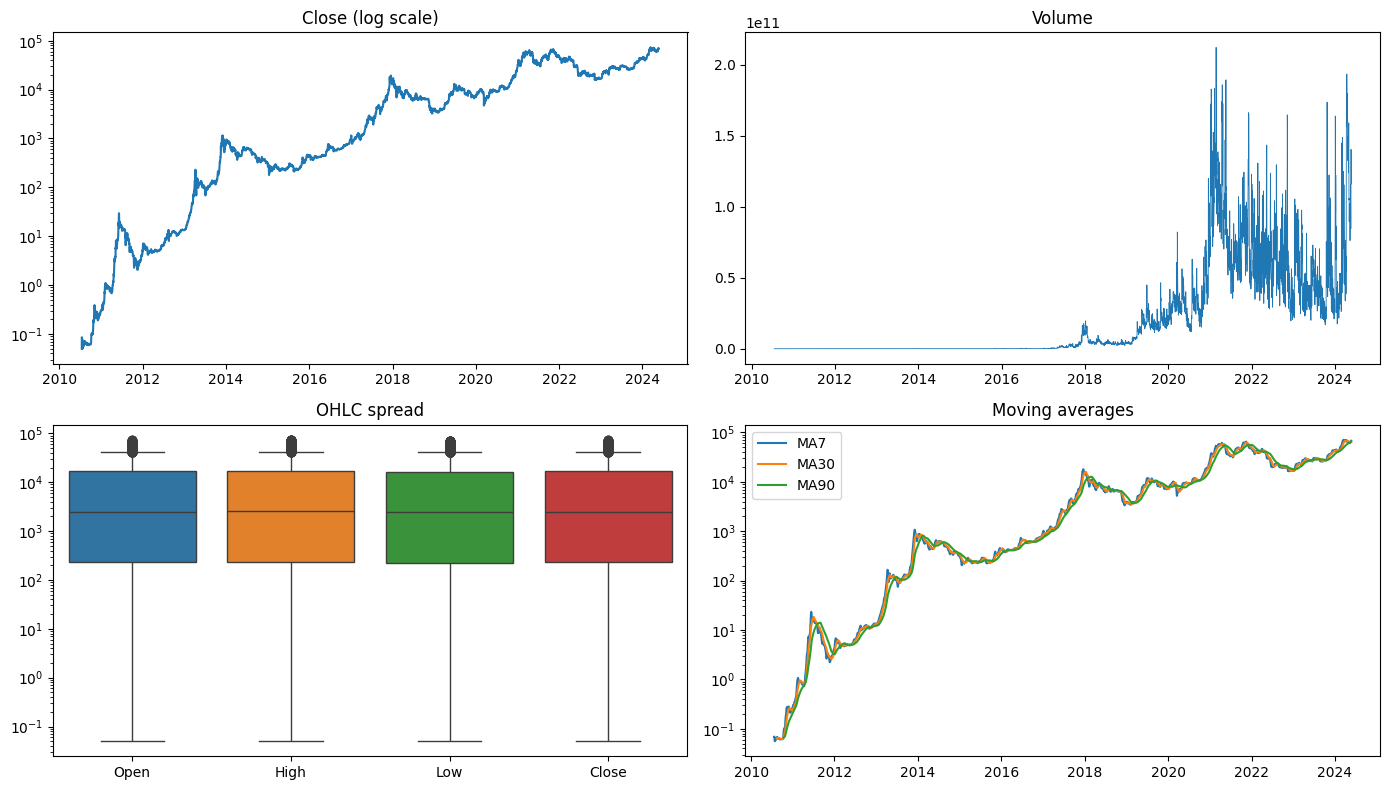

In [4]:
# Price trend (log scale), volume, OHLC spread
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0,0].plot(raw.index, raw['Close']); ax[0,0].set_yscale('log'); ax[0,0].set_title('Close (log scale)')
ax[0,1].plot(raw.index, raw['Volume'], lw=.6); ax[0,1].set_title('Volume')
sns.boxplot(data=raw[['Open','High','Low','Close']], ax=ax[1,0]); ax[1,0].set_yscale('log'); ax[1,0].set_title('OHLC spread')
ax[1,1].plot(raw['Close'].rolling(7).mean(),  label='MA7')
ax[1,1].plot(raw['Close'].rolling(30).mean(), label='MA30')
ax[1,1].plot(raw['Close'].rolling(90).mean(), label='MA90')
ax[1,1].set_yscale('log'); ax[1,1].legend(); ax[1,1].set_title('Moving averages')
plt.tight_layout(); plt.show()


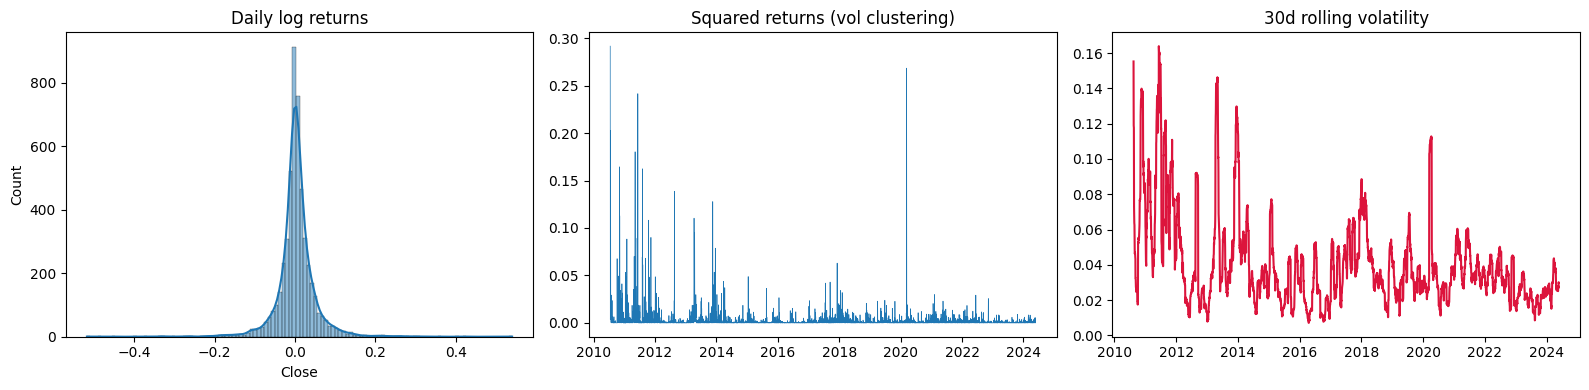

mean=0.00280  std=0.04998  skew=-0.220  kurtosis=17.604


In [5]:
# Return distribution + volatility clustering
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(ret, bins=120, kde=True, ax=ax[0]); ax[0].set_title('Daily log returns')
ax[1].plot(ret.index, ret**2, lw=.5);        ax[1].set_title('Squared returns (vol clustering)')
ax[2].plot(ret.index, ret.rolling(30).std(), color='crimson'); ax[2].set_title('30d rolling volatility')
plt.tight_layout(); plt.show()
print(f'mean={ret.mean():.5f}  std={ret.std():.5f}  skew={ret.skew():.3f}  kurtosis={ret.kurt():.3f}')


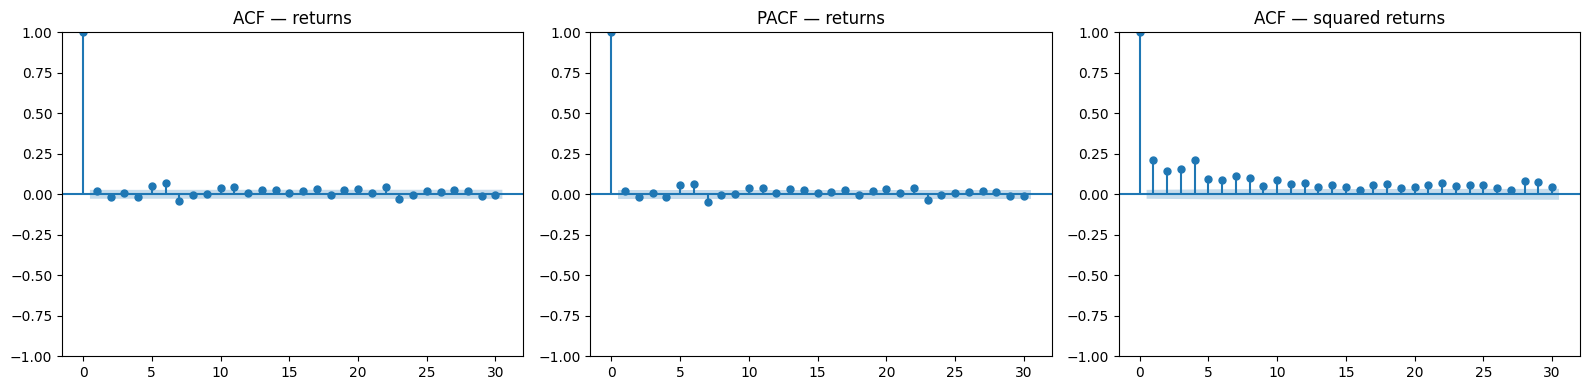

In [6]:
# Autocorrelation: ACF/PACF of returns + lag-by-lag autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plot_acf(ret, lags=30, ax=ax[0]);                 ax[0].set_title('ACF — returns')
plot_pacf(ret, lags=30, ax=ax[1], method='ywm');  ax[1].set_title('PACF — returns')
plot_acf(ret**2, lags=30, ax=ax[2]);              ax[2].set_title('ACF — squared returns')
plt.tight_layout(); plt.show()


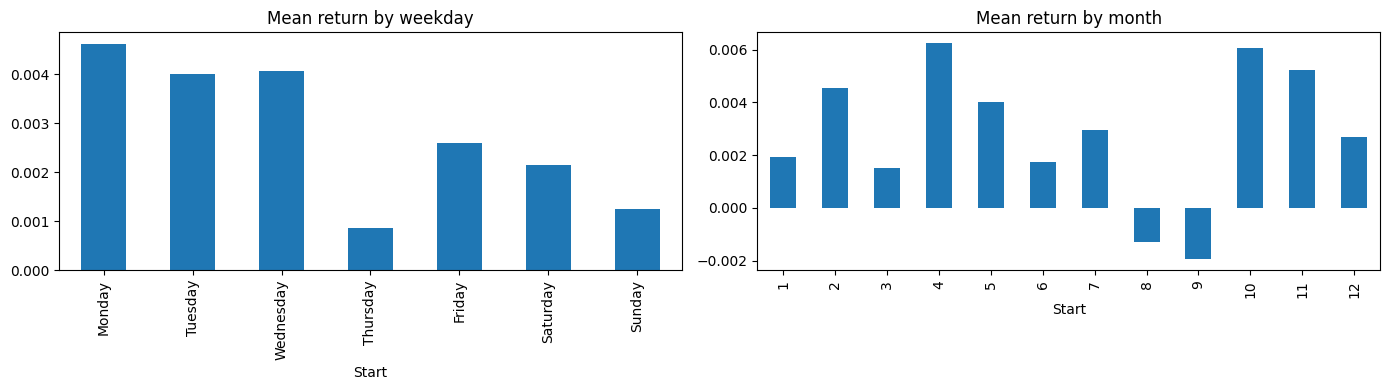

ADF  Close   : p=0.917  -> NON-stationary
ADF  Returns : p=0.0000 -> stationary
Weekday effect ANOVA: p=0.708
Month   effect ANOVA: p=0.299
(p > 0.05 -> differences are most likely noise)


In [7]:
# Seasonality + ADF stationarity
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ret.groupby(ret.index.day_name()).mean().reindex(order).plot(kind='bar', ax=ax[0]); ax[0].set_title('Mean return by weekday')
ret.groupby(ret.index.month).mean().plot(kind='bar', ax=ax[1]); ax[1].set_title('Mean return by month')
plt.tight_layout(); plt.show()

from statsmodels.tsa.stattools import adfuller
print(f"ADF  Close   : p={adfuller(raw['Close'].dropna())[1]:.3f}  -> {'stationary' if adfuller(raw['Close'].dropna())[1]<0.05 else 'NON-stationary'}")
print(f"ADF  Returns : p={adfuller(ret)[1]:.4f} -> {'stationary' if adfuller(ret)[1]<0.05 else 'NON-stationary'}")

# Significance of the weekday/month effects (don't claim seasonality without this)
from scipy.stats import f_oneway
wk = [g.values for _, g in ret.groupby(ret.index.day_name())]
mo = [g.values for _, g in ret.groupby(ret.index.month)]
print(f"Weekday effect ANOVA: p={f_oneway(*wk).pvalue:.3f}")
print(f"Month   effect ANOVA: p={f_oneway(*mo).pvalue:.3f}")
print("(p > 0.05 -> differences are most likely noise)")


**EDA takeaways that drive the design.** Returns are stationary (ADF p≈0) but near-random: weak/short autocorrelation, fat tails (kurtosis ≈ 17), and *no* significant weekday/month seasonality (ANOVA p > 0.05). Squared returns, by contrast, autocorrelate strongly — **volatility clusters**. So we expect: magnitude ≈ unpredictable, a possible faint direction signal from momentum/mean-reversion/volume, and volatility as the most persistent property.

## 2. The CORE Feature Set (15 features)
A deliberately small, interpretable set — every feature maps to a family the EDA flagged, and collinear duplicates are dropped (e.g. `stoch_k` represents the stochastic family; `rsi_14` over `rsi_30`). Each is **trailing-only** (no look-ahead); price enters as **ratios** to stay stationary across the 2010→2024 range.

| Family | Features | Rationale |
|---|---|---|
| Momentum | `ret_1, ret_3, ret_7, ret_lag1` | short-horizon trend / persistence |
| Mean-reversion | `rsi_14, stoch_k, bb_pctb, zscore_30` | strongest single-feature correlations in EDA |
| Volume / flow | `mfi_14, rel_volume` | money-flow + relative participation |
| Volatility | `vol_30, parkinson` | the one property that *clusters* |
| Trend / regime | `close_ma200, bull` | long-run regime context |
| Interaction | `ret3_x_vol7` | only cross-term with real EDA correlation |

In [8]:
# ===== CORE feature builder (15 features) + shared eval helpers =====
import numpy as np, pandas as pd
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, roc_auc_score, confusion_matrix)
try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBRegressor, XGBClassifier

def build_core_features(raw):
    """15 trailing-only, stationary features grouped by family (see table above)."""
    O,H,L,C,V,M = (raw['Open'],raw['High'],raw['Low'],raw['Close'],raw['Volume'],raw['Market Cap'])
    f  = pd.DataFrame(index=raw.index)
    r1 = np.log(C / C.shift(1))
    def _rsi(p, n):
        d = p.diff(); up = d.clip(lower=0); dn = -d.clip(upper=0)
        return 100 - 100/(1 + up.rolling(n).mean()/dn.rolling(n).mean())
    # Momentum
    f['ret_1'], f['ret_3'], f['ret_7'] = r1, np.log(C/C.shift(3)), np.log(C/C.shift(7))
    f['ret_lag1'] = r1.shift(1)
    # Mean-reversion oscillators
    f['rsi_14'] = _rsi(C, 14)
    lo14, hi14  = L.rolling(14).min(), H.rolling(14).max()
    f['stoch_k'] = 100*(C - lo14)/(hi14 - lo14)
    mb, sd      = C.rolling(20).mean(), C.rolling(20).std()
    f['bb_pctb']   = (C - (mb - 2*sd))/(4*sd)
    f['zscore_30'] = (C - C.rolling(30).mean())/C.rolling(30).std()
    # Volume / money flow
    tp = (H+L+C)/3; mf = tp*V
    pos = mf.where(tp>tp.shift(),0).rolling(14).sum(); neg = mf.where(tp<tp.shift(),0).rolling(14).sum()
    f['mfi_14']     = 100 - 100/(1 + pos/neg)
    f['rel_volume'] = V / V.rolling(30).mean()
    # Volatility
    f['vol_30']    = r1.rolling(30).std()
    f['parkinson'] = np.sqrt((np.log(H/L)**2/(4*np.log(2))).rolling(14).mean())
    # Trend / regime
    f['close_ma200'] = C / C.rolling(200).mean()
    f['bull']        = (C > C.rolling(200).mean()).astype(int)
    # Interaction
    f['ret3_x_vol7'] = np.log(C/C.shift(3)) * r1.rolling(7).std()
    return f, r1

FEAT, R1 = build_core_features(raw)
CLOSE = raw['Close']

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)); mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred); da = np.mean(np.sign(y_pred)==np.sign(y_true))*100
    print(f"{name:16s} RMSE={rmse:.5f}  MAE={mae:.5f}  R2={r2:.4f}  DirAcc={da:.1f}%")

def split_xy(target, embargo, tr_end='2023-01-31', te0='2023-02-01', te1='2023-07-31'):
    """Time-based split; `embargo` drops the last train rows so a forward target can't peek."""
    d = FEAT.copy(); d['y'] = target
    d = d.replace([np.inf,-np.inf], np.nan).dropna()
    tr = d.loc[:tr_end]; tr = tr.iloc[:-embargo] if embargo else tr
    te = d.loc[te0:te1]
    return tr.drop(columns='y'), tr['y'], te.drop(columns='y'), te['y']

def reg_eval(name, yt, yp, direction=True):
    s = f'{name:16s} RMSE={np.sqrt(mean_squared_error(yt,yp)):.5f}  MAE={mean_absolute_error(yt,yp):.5f}  R2={r2_score(yt,yp):.4f}'
    if direction: s += f'  DirAcc={np.mean(np.sign(yp)==np.sign(yt))*100:.1f}%'
    print(s)

print(f'CORE ready: {FEAT.shape[1]} features, {len(FEAT)} rows '
      f'({FEAT.dropna().index.min().date()} -> {FEAT.dropna().index.max().date()})')

CORE ready: 15 features, 5059 rows (2013-12-27 -> 2024-05-22)


In [9]:
FEAT

,ret_1,ret_3,ret_7,ret_lag1,rsi_14,stoch_k,bb_pctb,zscore_30,mfi_14,rel_volume,vol_30,parkinson,close_ma200,bull,ret3_x_vol7
Start,,,,,,,,,,,,,,,
2010-07-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2010-07-18,0.539996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2010-07-19,-0.060042,NaN,NaN,0.539996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2010-07-20,-0.078497,0.401457,NaN,-0.060042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2010-07-21,0.058496,-0.080043,NaN,-0.078497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-18,-0.001336,0.010017,0.096086,0.026527,58.368735,93.145756,0.932612,1.584804,64.679898,0.791001,0.026877,0.022550,1.286765,1,0.000316
2024-05-19,-0.008518,0.016674,0.075050,-0.001336,56.222441,82.811253,0.842413,1.258022,58.058392,0.731644,0.026909,0.022572,1.272070,1,0.000545
2024-05-20,0.073653,0.063799,0.126733,-0.008518,68.055390,99.655407,1.145050,2.863808,58.409785,0.860625,0.029923,0.025016,1.364524,1,0.002588


### Screening evidence
Two quick views confirm the CORE features carry only weak, distributed signal — no single feature dominates (which is *itself* the finding, and why parsimony is safe).

In [10]:
# |correlation| with next-day return, and train-only RandomForest importance
from sklearn.ensemble import RandomForestRegressor
tmp = FEAT.copy(); tmp['target'] = R1.shift(-1)
corr_t = tmp.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
print('|corr| of CORE features vs next-day return:')
print(corr_t.round(3).to_string())

d = FEAT.copy(); d['y'] = R1.shift(-1); d = d.replace([np.inf,-np.inf], np.nan).dropna()
tr = d.loc[:'2023-01-31']
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(tr.drop(columns='y'), tr['y'])
imp = pd.Series(rf.feature_importances_, index=tr.drop(columns='y').columns).sort_values(ascending=False)
print('\nRandomForest importance (train only):')
print(imp.round(3).to_string())
print('\n(No feature exceeds ~0.07 |corr|; importances are near-uniform -> signal is weak and aggregate.)')

|corr| of CORE features vs next-day return:
rsi_14         0.085
zscore_30      0.081
stoch_k        0.079
bb_pctb        0.075
mfi_14         0.064
close_ma200    0.053
ret_7          0.035
ret3_x_vol7    0.035
vol_30         0.023
bull           0.021
ret_1          0.020
ret_lag1       0.018
rel_volume     0.017
ret_3          0.008
parkinson      0.008

RandomForest importance (train only):
ret_1          0.091
zscore_30      0.088
close_ma200    0.087
ret_7          0.084
rel_volume     0.076
parkinson      0.073
ret_lag1       0.068
stoch_k        0.065
ret_3          0.065
ret3_x_vol7    0.064
mfi_14         0.064
vol_30         0.062
rsi_14         0.060
bb_pctb        0.052
bull           0.003

(No feature exceeds ~0.07 |corr|; importances are near-uniform -> signal is weak and aggregate.)


## 3. Models on the CORE Set
Leakage-safe time split (train ≤ 2023-01-31, 1-day embargo, test Feb–Jul 2023), one consistent scorecard.

### 3a. Return magnitude (regression) — expected near-zero

In [11]:
# Next-day log-return magnitude on the CORE set
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
target_mag = R1.shift(-1)
Xtr, ytr, Xte, yte = split_xy(target_mag, embargo=1)
print(f'magnitude | train={len(ytr)} test={len(yte)}')
evaluate('LinearReg',   yte, make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr).predict(Xte))
evaluate('RandomForest', yte, RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(Xtr, ytr).predict(Xte))
evaluate('XGBoost',     yte, XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=4, subsample=0.8,
                                          colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=5,
                                          random_state=42, n_jobs=-1).fit(Xtr, ytr).predict(Xte))
print('(R2 <= 0 across models -> next-day magnitude is unpredictable, as the EDA predicted.)')

magnitude | train=3322 test=181
LinearReg        RMSE=0.02459  MAE=0.01766  R2=-0.0571  DirAcc=47.0%
RandomForest     RMSE=0.02570  MAE=0.01856  R2=-0.1546  DirAcc=50.3%
XGBoost          RMSE=0.02568  MAE=0.01820  R2=-0.1526  DirAcc=52.5%
(R2 <= 0 across models -> next-day magnitude is unpredictable, as the EDA predicted.)


### 3b. Next-day direction (classification) — the one positive result

In [12]:
# Fit the base classifier once on the standard split — reused by tests 2-5
# (dedicated variable names so the experiments' yte/Xte/p can't clobber them)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
XGB_PARAMS = dict(n_estimators=400, learning_rate=0.02, max_depth=4, subsample=0.8,
                  colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)
target_B = (np.log(CLOSE.shift(-1) / CLOSE) > 0).astype(int)
Xc_tr, yc_tr, Xc_te, yc_te = split_xy(target_B, embargo=1)
clf      = XGBClassifier(**XGB_PARAMS).fit(Xc_tr, yc_tr)
p_dir    = clf.predict_proba(Xc_te)[:, 1]
pred_dir = (p_dir > 0.5).astype(int)
print(f'Base classifier   Acc={accuracy_score(yc_te,pred_dir):.3f}  ROC-AUC={roc_auc_score(yc_te,p_dir):.3f}  (test up-rate={yc_te.mean():.2f})')


Base classifier   Acc=0.508  ROC-AUC=0.571  (test up-rate=0.48)


In [13]:
# ===== EXPERIMENT B — next-day direction (classification) =====
target_B = (np.log(CLOSE.shift(-1) / CLOSE) > 0).astype(int)
Xtr, ytr, Xte, yte = split_xy(target_B, embargo=1)
print(f'B) direction  | train={len(ytr)}  test={len(yte)}  | up-rate train={ytr.mean():.2f} test={yte.mean():.2f}')

clf = XGBClassifier(n_estimators=400, learning_rate=0.02, max_depth=4, subsample=0.8,
                    colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1).fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]; pred = (p > 0.5).astype(int)
print(f'XGBClassifier   Acc={accuracy_score(yte,pred):.3f}  F1={f1_score(yte,pred):.3f}  ROC-AUC={roc_auc_score(yte,p):.3f}')

try:
    from catboost import CatBoostClassifier
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'catboost'])
    from catboost import CatBoostClassifier
cb = CatBoostClassifier(iterations=400, learning_rate=0.02, depth=4, verbose=0, random_state=42).fit(Xtr, ytr)
pc = cb.predict_proba(Xte)[:, 1]; predc = (pc > 0.5).astype(int)
print(f'CatBoost        Acc={accuracy_score(yte,predc):.3f}  F1={f1_score(yte,predc):.3f}  ROC-AUC={roc_auc_score(yte,pc):.3f}')
print('(ROC-AUC ~0.50 = no directional edge; >0.55 starts to be interesting)')


B) direction  | train=3322  test=181  | up-rate train=0.53 test=0.48
XGBClassifier   Acc=0.508  F1=0.570  ROC-AUC=0.571
CatBoost        Acc=0.497  F1=0.588  ROC-AUC=0.515
(ROC-AUC ~0.50 = no directional edge; >0.55 starts to be interesting)


### 3c. Forward 30-day volatility, and a 7-day return horizon

In [14]:
# ===== EXPERIMENT C — future 30-day realized volatility =====
target_C = R1.rolling(30).std().shift(-30)                # std of the NEXT 30 daily returns
Xtr, ytr, Xte, yte = split_xy(target_C, embargo=30)
print(f'C) future 30d volatility  | train={len(ytr)}  test={len(yte)}')
reg_eval('XGB',  yte, XGBRegressor(n_estimators=400, learning_rate=0.02, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   n_jobs=-1).fit(Xtr, ytr).predict(Xte), direction=False)
reg_eval('RandomForest', yte, RandomForestRegressor(n_estimators=300, random_state=42,
                                                    n_jobs=-1).fit(Xtr, ytr).predict(Xte), direction=False)
print('(Expect the strongest R2 here — volatility persists, unlike returns.)')


C) future 30d volatility  | train=3293  test=181
XGB              RMSE=0.01337  MAE=0.01114  R2=-2.6247
RandomForest     RMSE=0.01751  MAE=0.01374  R2=-5.2179
(Expect the strongest R2 here — volatility persists, unlike returns.)


In [31]:
# ===== EXPERIMENT  D— 7-day forward return =====
target_A = np.log(CLOSE.shift(-7) / CLOSE)                 # cumulative next-7-day log return
Xtr, ytr, Xte, yte = split_xy(target_A, embargo=7)
print(f'A) 7-day return  | train={len(ytr)}  test={len(yte)}')
reg_eval('XGB',  yte, XGBRegressor(n_estimators=400, learning_rate=0.02, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42,
                                   n_jobs=-1).fit(Xtr, ytr).predict(Xte))
reg_eval('RandomForest', yte, RandomForestRegressor(n_estimators=300, random_state=42,
                                                    n_jobs=-1).fit(Xtr, ytr).predict(Xte))


A) 7-day return  | train=3316  test=181
XGB              RMSE=0.07793  MAE=0.05512  R2=-0.3003  DirAcc=48.6%
RandomForest     RMSE=0.08383  MAE=0.06029  R2=-0.5049  DirAcc=47.5%


LSTM PIPELINE SETUP

In [27]:
# ===== LSTM PIPELINE SETUP =====
import os
import sys
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, roc_auc_score

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
except ImportError:
    print("Installing PyTorch...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

# LSTM Network Architecture
class LSTMNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1, output_dim=1, is_classifier=False):
        super(LSTMNetwork, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.is_classifier = is_classifier

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        out, _ = self.lstm(x)
        # select last time step output
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        if self.is_classifier:
            out = torch.sigmoid(out)
        return out

# Training Loop with Early Stopping
def train_lstm_model(model, train_loader, val_loader, epochs=100, lr=0.001, is_classifier=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.BCELoss() if is_classifier else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_loss = float('inf')
    best_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch).squeeze(-1)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                preds_val = model(X_val).squeeze(-1)
                loss_val = criterion(preds_val, y_val)
                val_loss += loss_val.item() * X_val.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = model.state_dict().copy()

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model

# Sequence building helpers
def get_lstm_sequences(X_tr, y_tr, X_te, y_te, seq_length=10):
    # Scale features (fit on train only)
    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_scaled = pd.DataFrame(scaler.transform(X_te), columns=X_te.columns, index=X_te.index)

    # Sequence building for training
    X_tr_seq, y_tr_seq = [], []
    for i in range(len(X_tr_scaled) - seq_length + 1):
        X_tr_seq.append(X_tr_scaled.iloc[i:(i + seq_length)].values)
        y_tr_seq.append(y_tr.iloc[i + seq_length - 1])

    # Sequence building for testing (prepend train tail to prevent losing first test rows)
    X_te_combined = pd.concat([X_tr_scaled.iloc[-(seq_length - 1):], X_te_scaled], axis=0)
    y_te_combined = pd.concat([y_tr.iloc[-(seq_length - 1):], y_te], axis=0)
    X_te_seq, y_te_seq = [], []
    for i in range(len(X_te_combined) - seq_length + 1):
        X_te_seq.append(X_te_combined.iloc[i:(i + seq_length)].values)
        y_te_seq.append(y_te_combined.iloc[i + seq_length - 1])

    return np.array(X_tr_seq), np.array(y_tr_seq), np.array(X_te_seq), np.array(y_te_seq)

In [28]:
# ===== EXPERIMENT E: LSTM NEXT-DAY LOG RETURN REGRESSION =====
print("="*80)
print("EXPERIMENT E: LSTM NEXT-DAY LOG RETURN REGRESSION")
print("="*80)
seq_length = 10
# Reuse features_df, target_next_day, and split_data from the notebook baseline block
X_tr, y_tr, X_te, y_te = split_xy(target_A, embargo=1)
X_tr_seq, y_tr_seq, X_te_seq, y_te_seq = get_lstm_sequences(X_tr, y_tr, X_te, y_te, seq_length=seq_length)

val_split_size = int(len(X_tr_seq) * 0.1)
X_train_part, y_train_part = X_tr_seq[:-val_split_size], y_tr_seq[:-val_split_size]
X_val_part, y_val_part = X_tr_seq[-val_split_size:], y_tr_seq[-val_split_size:]

train_ds = TensorDataset(torch.tensor(X_train_part, dtype=torch.float32), torch.tensor(y_train_part, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val_part, dtype=torch.float32), torch.tensor(y_val_part, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

# Build & Train
input_dim = X_tr_seq.shape[2]
lstm_reg = LSTMNetwork(input_dim=input_dim, hidden_dim=32, num_layers=1, output_dim=1, is_classifier=False)

print("Training LSTM Regressor...")
lstm_reg = train_lstm_model(lstm_reg, train_loader, val_loader, epochs=100, lr=0.001, is_classifier=False)

# Evaluate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lstm_reg.to(device)
lstm_reg.eval()
with torch.no_grad():
    preds_reg = lstm_reg(torch.tensor(X_te_seq, dtype=torch.float32).to(device)).squeeze(-1).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_te_seq, preds_reg))
mae = mean_absolute_error(y_te_seq, preds_reg)
r2 = r2_score(y_te_seq, preds_reg)
da = np.mean(np.sign(preds_reg) == np.sign(y_te_seq)) * 100
print(f"LSTM Regressor Results:")
print(f"R² Score              = {r2:.5f}")
print(f"RMSE                  = {rmse:.5f}")
print(f"MAE                   = {mae:.5f}")
print(f"Directional Accuracy  = {da:.2f}%")

EXPERIMENT E: LSTM NEXT-DAY LOG RETURN REGRESSION
Training LSTM Regressor...
Epoch  20/100 | Train Loss: 0.010017 | Val Loss: 0.008605
Epoch  40/100 | Train Loss: 0.009097 | Val Loss: 0.008552
Epoch  60/100 | Train Loss: 0.007738 | Val Loss: 0.008900
Epoch  80/100 | Train Loss: 0.006608 | Val Loss: 0.011455
Epoch 100/100 | Train Loss: 0.005283 | Val Loss: 0.011113
LSTM Regressor Results:
R² Score              = -2.28747
RMSE                  = 0.12391
MAE                   = 0.08950
Directional Accuracy  = 48.07%


In [30]:
# ===== EXPERIMENT F: LSTM NEXT-DAY DIRECTION CLASSIFICATION =====
print("\n" + "="*80)
print("EXPERIMENT F: LSTM NEXT-DAY DIRECTION CLASSIFICATION")
print("="*80)
# Reuse features_df, target_dir, and split_data from the notebook baseline block
X_tr_c, y_tr_c, X_te_c, y_te_c = split_xy(target_B,embargo=1)
X_tr_seq_c, y_tr_seq_c, X_te_seq_c, y_te_seq_c = get_lstm_sequences(X_tr_c, y_tr_c, X_te_c, y_te_c, seq_length=seq_length)

val_split_size_c = int(len(X_tr_seq_c) * 0.1)
X_train_part_c, y_train_part_c = X_tr_seq_c[:-val_split_size_c], y_tr_seq_c[:-val_split_size_c]
X_val_part_c, y_val_part_c = X_tr_seq_c[-val_split_size_c:], y_tr_seq_c[-val_split_size_c:]

train_ds_c = TensorDataset(torch.tensor(X_train_part_c, dtype=torch.float32), torch.tensor(y_train_part_c, dtype=torch.float32))
val_ds_c = TensorDataset(torch.tensor(X_val_part_c, dtype=torch.float32), torch.tensor(y_val_part_c, dtype=torch.float32))

train_loader_c = DataLoader(train_ds_c, batch_size=64, shuffle=False)
val_loader_c = DataLoader(val_ds_c, batch_size=64, shuffle=False)

# Build & Train
lstm_clf = LSTMNetwork(input_dim=input_dim, hidden_dim=32, num_layers=1, output_dim=1, is_classifier=True)

print("Training LSTM Classifier...")
lstm_clf = train_lstm_model(lstm_clf, train_loader_c, val_loader_c, epochs=100, lr=0.001, is_classifier=True)

# Evaluate
lstm_clf.to(device)
lstm_clf.eval()
with torch.no_grad():
    preds_prob = lstm_clf(torch.tensor(X_te_seq_c, dtype=torch.float32).to(device)).squeeze(-1).cpu().numpy()
preds_labels = (preds_prob > 0.5).astype(int)

acc = accuracy_score(y_te_seq_c, preds_labels)
f1 = f1_score(y_te_seq_c, preds_labels)
auc = roc_auc_score(y_te_seq_c, preds_prob)
print(f"LSTM Classifier Results:")
print(f"Accuracy  = {acc:.4f}")
print(f"F1-Score  = {f1:.4f}")
print(f"ROC-AUC   = {auc:.4f}")


EXPERIMENT F: LSTM NEXT-DAY DIRECTION CLASSIFICATION
Training LSTM Classifier...
Epoch  20/100 | Train Loss: 0.672271 | Val Loss: 0.695042
Epoch  40/100 | Train Loss: 0.634180 | Val Loss: 0.725234
Epoch  60/100 | Train Loss: 0.565207 | Val Loss: 0.832970
Epoch  80/100 | Train Loss: 0.467538 | Val Loss: 0.991775
Epoch 100/100 | Train Loss: 0.397396 | Val Loss: 1.135262
LSTM Classifier Results:
Accuracy  = 0.5083
F1-Score  = 0.5436
ROC-AUC   = 0.5220


## 4. Direction Validation Battery
The edge is small — so stress-test it. Each check asks: *is this real and usable, or noise?*

### Walk-Forward Validation
Train on all prior data, test each year separately. Stable AUC across years → real signal; AUC bouncing around 0.50 → noise.

 year  n_test  up_rate  accuracy  roc_auc
 2019     365     0.52     0.534    0.530
 2020     366     0.57     0.533    0.545
 2021     365     0.52     0.507    0.522
 2022     365     0.47     0.515    0.552
 2023     365     0.52     0.523    0.533
 2024     143     0.53     0.441    0.469

ROC-AUC across years:  mean=0.525   std=0.030
Verdict: looks NOISY / regime-dependent


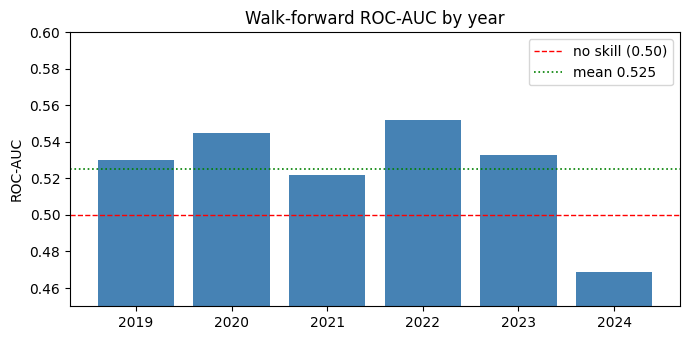

In [16]:
data = FEAT.copy(); data['y'] = target_B
data = data.replace([np.inf,-np.inf], np.nan).dropna()
rows = []
for yr in [2019, 2020, 2021, 2022, 2023, 2024]:
    tr = data.loc[:f'{yr-1}-12-31'].iloc[:-1]          # expanding window, 1-day embargo
    te = data.loc[f'{yr}-01-01':f'{yr}-12-31']
    if len(te) < 30: continue
    m = XGBClassifier(**XGB_PARAMS).fit(tr.drop(columns='y'), tr['y'])
    pp = m.predict_proba(te.drop(columns='y'))[:, 1]
    rows.append({'year': yr, 'n_test': len(te), 'up_rate': round(te['y'].mean(), 2),
                 'accuracy': round(accuracy_score(te['y'], (pp > .5).astype(int)), 3),
                 'roc_auc': round(roc_auc_score(te['y'], pp), 3)})
wf = pd.DataFrame(rows)
print(wf.to_string(index=False))
print(f"\nROC-AUC across years:  mean={wf.roc_auc.mean():.3f}   std={wf.roc_auc.std():.3f}")
print("Verdict:", "signal looks STABLE" if wf.roc_auc.mean() > 0.53 and wf.roc_auc.std() < 0.03 else "looks NOISY / regime-dependent")

plt.figure(figsize=(7, 3.5))
plt.bar(wf['year'].astype(str), wf['roc_auc'], color='steelblue')
plt.axhline(0.5, color='red', ls='--', lw=1, label='no skill (0.50)')
plt.axhline(wf['roc_auc'].mean(), color='green', ls=':', lw=1.2, label=f"mean {wf['roc_auc'].mean():.3f}")
plt.ylim(0.45, 0.60); plt.ylabel('ROC-AUC'); plt.title('Walk-forward ROC-AUC by year')
plt.legend(); plt.tight_layout(); plt.show()


### Feature Importance (XGBClassifier)
Which feature families drive the prediction — lagged returns, volume, volatility, trend, market cap?

stoch_k        0.072364
zscore_30      0.070985
rsi_14         0.070434
close_ma200    0.069903
ret_1          0.069487
ret_7          0.067652
ret3_x_vol7    0.067382
ret_3          0.067112
parkinson      0.066524
bb_pctb        0.066363
ret_lag1       0.065993
vol_30         0.065279
rel_volume     0.064352
mfi_14         0.063310
bull           0.052861


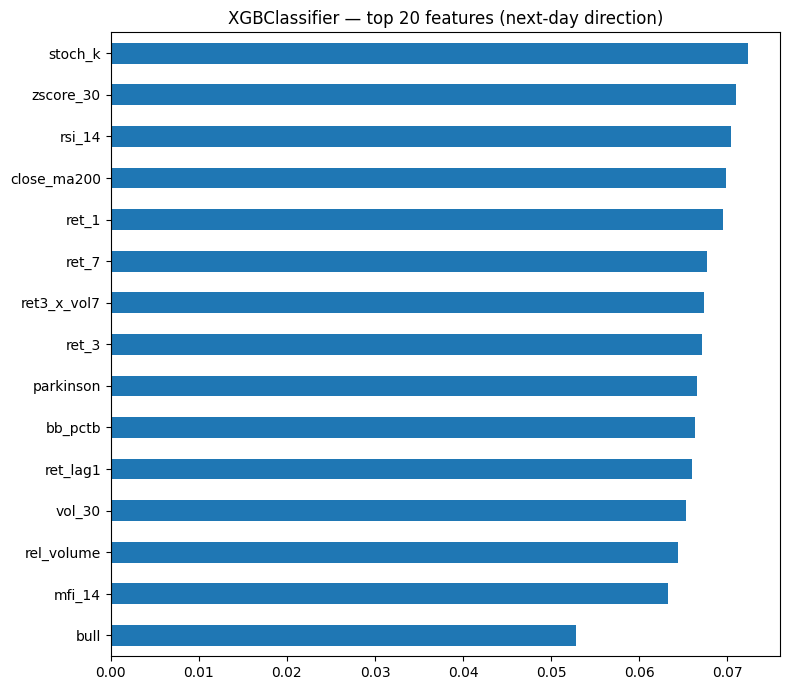

In [17]:
imp = pd.Series(clf.feature_importances_, index=Xc_tr.columns).sort_values(ascending=False)
print(imp.head(30).to_string())
plt.figure(figsize=(8, 7)); imp.head(20).iloc[::-1].plot(kind='barh')
plt.title('XGBClassifier — top 20 features (next-day direction)'); plt.tight_layout(); plt.show()


### Confusion Matrix
Is the model biased toward predicting UP (which just tracks market drift)?

In [18]:
cm = confusion_matrix(yc_te, pred_dir)
print('             pred_DOWN  pred_UP')
print(f'true_DOWN      {cm[0,0]:5d}    {cm[0,1]:5d}')
print(f'true_UP        {cm[1,0]:5d}    {cm[1,1]:5d}')
print(f'\nPredicted UP on {pred_dir.mean()*100:.0f}% of days  (actual UP days = {yc_te.mean()*100:.0f}%)')


             pred_DOWN  pred_UP
true_DOWN         33       62
true_UP           27       59

Predicted UP on 67% of days  (actual UP days = 48%)


### Threshold Testing
Accuracy on high-confidence predictions only — rising accuracy with the threshold means the probabilities are informative.

In [19]:
print(f'{"threshold":>10} {"coverage":>9} {"n":>5} {"accuracy":>9}')
for t in [0.50, 0.55, 0.60, 0.65]:
    mask = p_dir > t
    if mask.sum() == 0: continue
    acc = accuracy_score(yc_te[mask], (p_dir[mask] > 0.5).astype(int))
    print(f'{t:>10.2f} {mask.mean()*100:>8.0f}% {int(mask.sum()):>5} {acc:>9.3f}')


 threshold  coverage     n  accuracy
      0.50       67%   121     0.488
      0.55       43%    77     0.545
      0.60       24%    44     0.591
      0.65        6%    11     0.636


### Trading Evaluation
Rule: **long when p > 0.55, else cash.** Tests whether the edge survives becoming a position; compared against buy-and-hold over the test window.

Days in market : 43%   (77 of 181)
Strategy return: +9.44%     Buy & hold: +24.99%
Sharpe (ann.)  : 0.75
Win rate       : 54.55%
Max drawdown   : -13.80%


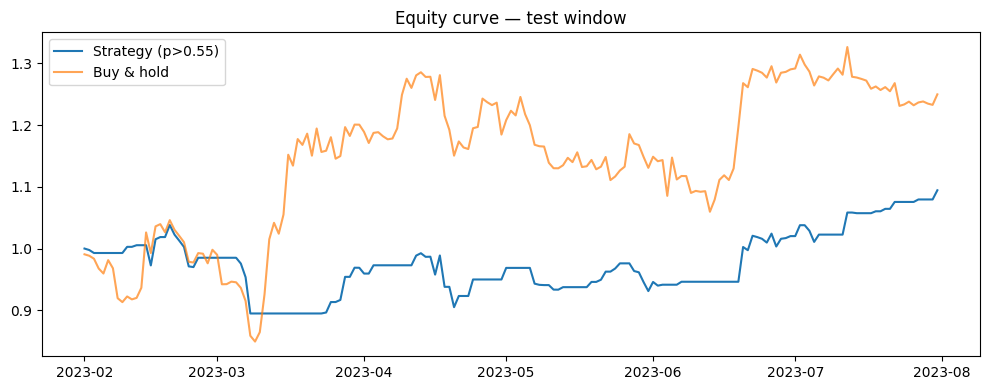

In [20]:
ret_next = np.log(CLOSE.shift(-1) / CLOSE).reindex(Xc_te.index).values   # realised next-day log return
pos   = (p_dir > 0.55).astype(int)
strat = pos * ret_next
eq    = np.exp(np.cumsum(strat))            # strategy equity curve
bh    = np.exp(np.cumsum(ret_next))         # buy & hold
sharpe = strat.mean() / (strat.std() + 1e-12) * np.sqrt(365)
maxdd  = (eq / np.maximum.accumulate(eq) - 1).min()
win    = (ret_next[pos == 1] > 0).mean() if pos.sum() else float('nan')
print(f'Days in market : {pos.mean()*100:.0f}%   ({int(pos.sum())} of {len(pos)})')
print(f'Strategy return: {eq[-1]-1:+.2%}     Buy & hold: {bh[-1]-1:+.2%}')
print(f'Sharpe (ann.)  : {sharpe:.2f}')
print(f'Win rate       : {win:.2%}')
print(f'Max drawdown   : {maxdd:.2%}')
plt.figure(figsize=(10, 4))
plt.plot(Xc_te.index, eq, label='Strategy (p>0.55)')
plt.plot(Xc_te.index, bh, label='Buy & hold', alpha=.7)
plt.legend(); plt.title('Equity curve — test window'); plt.tight_layout(); plt.show()


### Direction at a 7-Day Horizon
`target = (Close[t+7] > Close[t])` — does signal emerge at a longer horizon?

In [21]:
target_7d = (CLOSE.shift(-7) > CLOSE).astype(int)
X7tr, y7tr, X7te, y7te = split_xy(target_7d, embargo=7)
clf7 = XGBClassifier(**XGB_PARAMS).fit(X7tr, y7tr)
p7   = clf7.predict_proba(X7te)[:, 1]; pred7 = (p7 > 0.5).astype(int)
print(f'7-day direction   Acc={accuracy_score(y7te,pred7):.3f}  F1={f1_score(y7te,pred7):.3f}  ROC-AUC={roc_auc_score(y7te,p7):.3f}')


7-day direction   Acc=0.492  F1=0.465  ROC-AUC=0.475


### Bull / Bear Regime Models
Train and test separately on `bull = Close > MA200` vs `bear`.

In [22]:
# rebuild `data` locally so this cell is independent of the walk-forward cell
data = FEAT.copy(); data['y'] = target_B
data = data.replace([np.inf,-np.inf], np.nan).dropna()
for name, val in [('BULL (Close>MA200)', 1), ('BEAR (Close<=MA200)', 0)]:
    sub = data[data['bull'] == val]
    rtr = sub.loc[:'2023-01-31'].iloc[:-1]; rte = sub.loc['2023-02-01':'2023-07-31']
    if len(rte) < 20 or rte['y'].nunique() < 2:
        print(f'{name:22s} not enough test data in this regime'); continue
    m  = XGBClassifier(**XGB_PARAMS).fit(rtr.drop(columns='y'), rtr['y'])
    pp = m.predict_proba(rte.drop(columns='y'))[:, 1]
    print(f'{name:22s} n={len(rte):4d}  Acc={accuracy_score(rte["y"],(pp>.5).astype(int)):.3f}  ROC-AUC={roc_auc_score(rte["y"],pp):.3f}')


BULL (Close>MA200)     n= 181  Acc=0.564  ROC-AUC=0.585
BEAR (Close<=MA200)    not enough test data in this regime


### Explainability (SHAP)
Signed, directional feature attributions for the direction model.

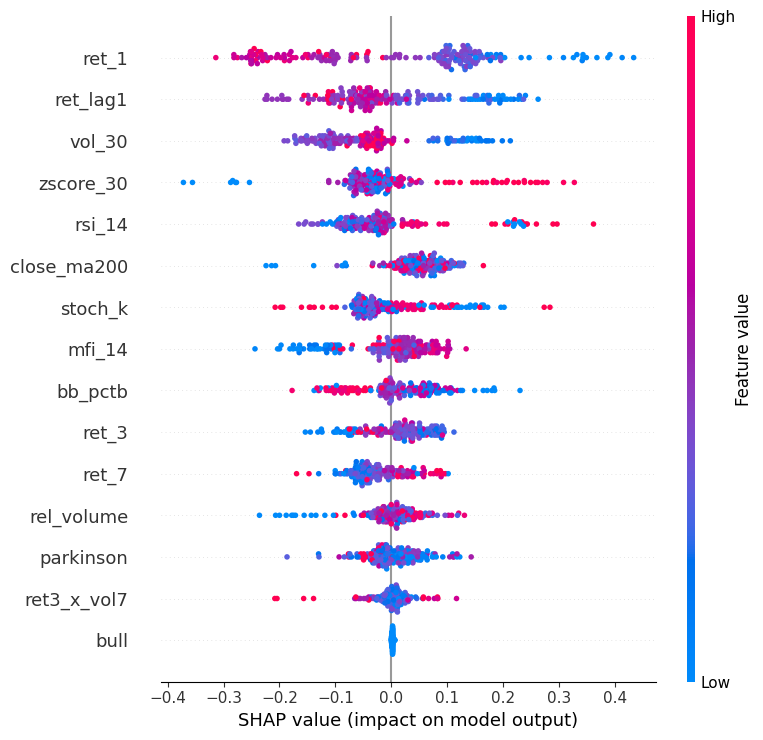

In [23]:
try:
    try:
        import shap
    except ImportError:
        import subprocess, sys; subprocess.run([sys.executable,'-m','pip','install','-q','shap']); import shap
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xc_te)
    shap.summary_plot(sv, Xc_te, max_display=15, show=True)
except Exception as e:
    print('SHAP skipped:', type(e).__name__, str(e)[:80])


## Robustness Check: Forecast Horizon Analysis

While the primary objective of this study is next-day Bitcoin return prediction, an additional robustness analysis was conducted to examine whether predictive performance varies across different investment horizons.

A Random Forest benchmark model was trained using the same engineered feature set to forecast:

- 1-day ahead returns
- 7-day ahead returns
- 30-day ahead returns

The purpose of this experiment is to evaluate whether the information contained in technical and market-derived features becomes more useful over longer horizons, where market noise may have a reduced impact.

### Methodology

For each forecast horizon:

1. The target variable was redefined as the future log return over the corresponding horizon.
2. The feature engineering pipeline was kept unchanged.
3. A Random Forest Regressor was trained using the same chronological train-test split.
4. Performance was evaluated using:
   - RMSE (Root Mean Squared Error)
   - MAE (Mean Absolute Error)
   - R² Score
   - Directional Accuracy



In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

horizons = [1, 7, 30]

rows = []

for h in horizons:

    d = FEAT.copy()

    d['y'] = np.log(
        CLOSE.shift(-h) / CLOSE
    )

    d = d.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    tr = d.loc[:'2023-01-31']
    te = d.loc['2023-02-01':]

    Xtr = tr.drop(columns='y')
    ytr = tr['y']

    Xte = te.drop(columns='y')
    yte = te['y']

    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(Xtr,ytr)

    pred = rf.predict(Xte)

    rows.append([

        h,

        np.sqrt(
            mean_squared_error(
                yte,pred
            )
        ),

        mean_absolute_error(
            yte,pred
        ),

        r2_score(
            yte,pred
        ),

        (
            np.sign(pred)
            ==
            np.sign(yte)
        ).mean()
    ])

rolling_results = pd.DataFrame(
    rows,
    columns=[
        'Horizon',
        'RMSE',
        'MAE',
        'R2',
        'Directional_Accuracy'
    ]
)

rolling_results
best = rolling_results.loc[
    rolling_results['Directional_Accuracy'].idxmax()
]

print(
    f"Highest directional accuracy was observed "
    f"at the {best['Horizon']}-day horizon "
    f"({best['Directional_Accuracy']:.2%})."
)

Highest directional accuracy was observed at the 30.0-day horizon (51.90%).


### Results

The results indicate that predictive performance remains close to random chance for short horizons (1-day and 7-day forecasts), supporting the view that Bitcoin exhibits a high degree of short-term market efficiency.

A modest improvement in directional accuracy was observed for the 30-day horizon, suggesting that the engineered features may contain weak medium-term information that is less visible in next-day price movements.

Overall, the findings reinforce the central conclusion of this project: predicting Bitcoin returns is challenging, and any exploitable signal is relatively weak. However, the slight improvement at longer horizons suggests that medium-term trends may be more predictable than short-term fluctuations.

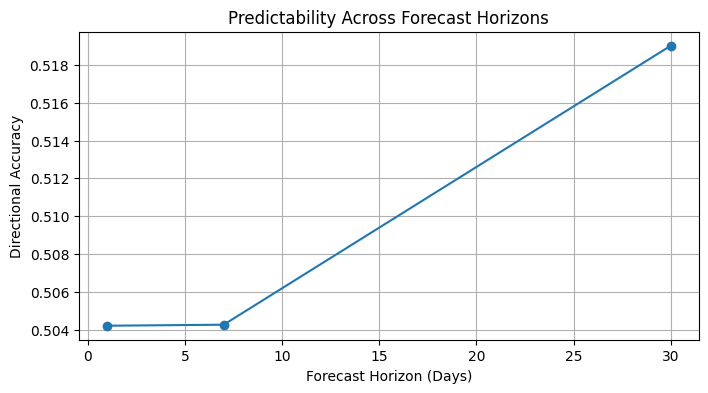

In [25]:


plt.figure(figsize=(8,4))

plt.plot(
    rolling_results['Horizon'],
    rolling_results['Directional_Accuracy'],
    marker='o'
)

plt.xlabel('Forecast Horizon (Days)')
plt.ylabel('Directional Accuracy')

plt.title(
    'Predictability Across Forecast Horizons'
)

plt.grid(True)

plt.show()

### CONCLUSION

Bitcoin returns remain difficult to predict, consistent with semi-strong market efficiency.
A compact set of 15 economically motivated features capturing momentum, mean reversion, volatility, volume, and market regime provides modest predictive power.
Walk-forward validation shows that performance is relatively stable across market regimes.
Feature parsimony improves interpretability and reduces the risk of overfitting.
Future work could incorporate on-chain metrics, macroeconomic variables, and sentiment indicators.